In [15]:
import os
import rasterio as rio
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

import Functions
import importlib

importlib.reload(Functions)

output_folder = Path('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents')
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Documents' / 'csv'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


Collecting the moisture from the excel

In [16]:
moisture = pd.read_excel('/home/frank/Desktop/f.chiapperino_local'
                        '/VALENCIA/SCUOLA/App/Ground_Campaign_untouched/Flevoland_data/Data_25_fields/Average_Soil_moisture.xlsx',
                        header=1)
moisture.drop(columns=['Unnamed: 0','Unnamed: 1'], inplace=True)
moisture.set_index('Code',inplace=True)
moisture = moisture[moisture.index.notna()]

moisture_date = list(pd.to_datetime(moisture.columns))

moisture = moisture.reset_index().melt(id_vars='Code', var_name='Date', value_name='Moist_situ')
moisture.dropna(subset='Moist_situ', inplace=True)
moisture.set_index(pd.to_datetime(moisture['Date']),inplace=True)
moisture.drop(columns='Date',inplace=True)


Interpolation of the SSM in situ: in this way we have a daily SSM.

In [17]:
from scipy.interpolate import pchip_interpolate

lista_dataframe_puliti = []

for c in moisture['Code'].unique():

    df = moisture[moisture['Code'] == c].copy()
    raggio_date_giornaliero = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    df = df.reindex(raggio_date_giornaliero)
    df.reset_index(names='Date', inplace=True)
    df['Code'] = c

    df['Umidita_PCHIP_%'] = df['Moist_situ'].interpolate(method='pchip')

    lista_dataframe_puliti.append(df)

df_generale = pd.concat(lista_dataframe_puliti, ignore_index=True)

df_generale = df_generale[['Date', 'Code', 'Moist_situ', 'Umidita_PCHIP_%']]
df_generale.sort_values(by=['Code', 'Date'], inplace=True, ignore_index=True)

display(df_generale[df_generale['Code'] == 1697689].iloc[0:20])

,Date,Code,Moist_situ,Umidita_PCHIP_%
473,2017-06-30,1697689.0,35.025,35.025000
474,2017-07-01,1697689.0,NaN,35.686766
475,2017-07-02,1697689.0,NaN,36.246939
476,2017-07-03,1697689.0,NaN,36.713985
477,2017-07-04,1697689.0,NaN,37.096370
478,2017-07-05,1697689.0,NaN,37.402560
479,2017-07-06,1697689.0,NaN,37.641022
480,2017-07-07,1697689.0,NaN,37.820221
481,2017-07-08,1697689.0,NaN,37.948623
482,2017-07-09,1697689.0,NaN,38.034695


Plot of the SSM for the parcel 2081267: the dots are the in-situ data and the line is the interpolated.

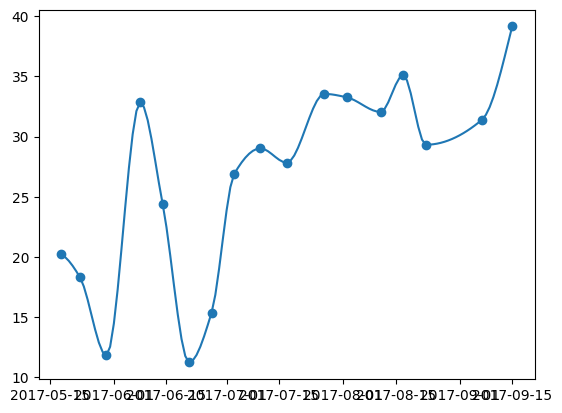

In [18]:
plt.plot(df_generale[df_generale['Code'] == 2081267]['Date'], df_generale[df_generale['Code'] == 2081267]['Umidita_PCHIP_%'])
plt.scatter(df_generale[df_generale['Code'] ==  2081267]['Date'], df_generale[df_generale['Code']==2081267]['Moist_situ'])

Collecting the backscatter data from a csv

In [19]:
sigma_TM = pd.DataFrame(pd.read_csv(input_path / 'TimeSeries_sigma.csv'))
sigma_TM['Date'] = pd.to_datetime(sigma_TM['Date'])
sigma_TM.drop(sigma_TM[sigma_TM['mean'] == 0].index,inplace=True)

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date'])

display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type
1298,1545384,20170104_VH,-15.490180,1.038437,2017-01-04,VH,DB_SB2_C,Potatoes
1300,1545384,20170110_VH,-14.146261,1.136036,2017-01-10,VH,DB_SB2_C,Potatoes
1302,1545384,20170116_VH,-20.622658,0.922879,2017-01-16,VH,DB_SB2_C,Potatoes
1304,1545384,20170122_VH,-22.050701,0.694627,2017-01-22,VH,DB_SB2_C,Potatoes
1306,1545384,20170128_VH,-16.818918,0.731224,2017-01-28,VH,DB_SB2_C,Potatoes
...,...,...,...,...,...,...,...,...
935,2278835,20171206_VV,-6.205426,0.920910,2017-12-06,VV,PVD-M-C,Corn
937,2278835,20171212_VV,-11.775089,0.645342,2017-12-12,VV,PVD-M-C,Corn
939,2278835,20171218_VV,-5.921874,1.043583,2017-12-18,VV,PVD-M-C,Corn
941,2278835,20171224_VV,-6.724238,1.070252,2017-12-24,VV,PVD-M-C,Corn


Merged the SSM (interpolated) with the values of backscatter only on the dates that coincide



In [20]:
sigma_TM = pd.merge(
    sigma_TM, 
    df_generale, 
    on=['Code', 'Date'], 
    how='right' 
).dropna(subset='mean')
display(sigma_TM[(sigma_TM['Code'] == 2081267) & (sigma_TM['Band'] == 'VH')])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%
2163,2081267.0,20170522_VH,-25.389317,1.711563,2017-05-22,VH,RBW_T_C,Wheat,NaN,18.812433
2170,2081267.0,20170528_VH,-24.257484,1.518813,2017-05-28,VH,RBW_T_C,Wheat,NaN,12.892751
2177,2081267.0,20170603_VH,-23.890009,1.827846,2017-06-03,VH,RBW_T_C,Wheat,NaN,20.592627
2184,2081267.0,20170609_VH,-21.061653,2.080115,2017-06-09,VH,RBW_T_C,Wheat,NaN,32.445287
2191,2081267.0,20170615_VH,-21.572351,1.709064,2017-06-15,VH,RBW_T_C,Wheat,NaN,22.467302
2204,2081267.0,20170627_VH,-21.209030,1.516124,2017-06-27,VH,RBW_T_C,Wheat,15.3750,15.375000
2211,2081267.0,20170703_VH,-18.438747,1.369807,2017-07-03,VH,RBW_T_C,Wheat,26.8875,26.887500
2218,2081267.0,20170709_VH,-19.987783,1.144082,2017-07-09,VH,RBW_T_C,Wheat,NaN,28.972333
2225,2081267.0,20170715_VH,-18.622576,1.071620,2017-07-15,VH,RBW_T_C,Wheat,NaN,28.072923
2232,2081267.0,20170721_VH,-20.037262,1.200830,2017-07-21,VH,RBW_T_C,Wheat,NaN,29.848300


Regression between SSM_PCHIP and VV and VH

In [32]:
from scipy import stats

results_regression_VV = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    VV = gruppo['mean'].values
    SSM_ret = gruppo['Umidita_PCHIP_%'].values

    if len(VV) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(VV, SSM_ret)        
        y_pred = slope * VV + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression_VV.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(VV),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche_VV = pd.DataFrame(results_regression_VV)
df_statistiche_VV.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche_VV)


,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
13,1698168.0,TK_MA_C,VV,Corn,7,0.995224,0.990471,0.000003,3.229408,68.918611,0.656911
12,1698168.0,TK_MA_C,VH,Corn,7,0.992692,0.985438,0.000009,2.217600,72.133361,0.812088
22,1936133.0,AKW_A_C,VH,Potatoes,13,0.922176,0.850409,0.000007,1.506481,46.872084,1.382353
9,1697689.0,SB7_ER_C,VV,Grassland,8,-0.889512,0.791232,0.003099,-1.938168,6.969649,1.572151
28,2041694.0,HF1-CA-C,VH,Potatoes,12,0.887854,0.788285,0.000115,1.674644,50.187064,2.771659
31,2081267.0,RBW_T_C,VV,Wheat,14,0.843634,0.711718,0.000149,2.046857,55.292704,3.470898
27,1936135.0,AKW_T_C,VV,Wheat,14,0.836770,0.700184,0.000190,2.023606,50.741656,3.096890
32,2081268.0,RBW_A_C,VH,Potatoes,14,0.830141,0.689135,0.000238,1.280214,47.136893,2.518999
33,2081268.0,RBW_A_C,VV,Potatoes,14,0.826320,0.682804,0.000270,2.053913,44.965963,2.544519
35,2081887.0,SB10_MA_C,VV,Corn,11,0.798232,0.637175,0.003227,1.193186,40.651103,1.458253


In [21]:
sigma_TM['diff_mean'] = -sigma_TM.groupby(['Code', 'Band'])['mean'].diff(periods=-1)
sigma_TM['diff_lin'] = 10 ** (sigma_TM['diff_mean']/10)
sigma_TM['T'] = sigma_TM.groupby(['Code', 'Band'])['Date'].diff(periods=-1)
sigma_TM.insert(len(sigma_TM.columns)-1, 'Moist_situ', sigma_TM.pop('Moist_situ'))

sigma_TM = sigma_TM[sigma_TM['Umidita_PCHIP_%'] < 55]

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date']).reset_index(drop=True)
sigma_TM['situ'] = 0
display(sigma_TM.iloc[0:10])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Umidita_PCHIP_%,diff_mean,diff_lin,T,Moist_situ
0,1545384.0,20170522_VH,-25.417510,0.981700,2017-05-22,VH,DB_SB2_C,Potatoes,17.702953,3.389380,2.182418,-6 days,NaN
1,1545384.0,20170528_VH,-22.028130,1.283643,2017-05-28,VH,DB_SB2_C,Potatoes,20.562807,2.548216,1.798132,-6 days,NaN
2,1545384.0,20170603_VH,-19.479914,0.890061,2017-06-03,VH,DB_SB2_C,Potatoes,23.020128,4.836104,3.045162,-6 days,NaN
3,1545384.0,20170609_VH,-14.643810,1.127511,2017-06-09,VH,DB_SB2_C,Potatoes,23.497828,-2.752335,0.530599,-6 days,NaN
4,1545384.0,20170615_VH,-17.396145,0.856844,2017-06-15,VH,DB_SB2_C,Potatoes,14.731250,0.539885,1.132370,-12 days,14.73125
5,1545384.0,20170627_VH,-16.856260,1.061146,2017-06-27,VH,DB_SB2_C,Potatoes,11.993750,2.260631,1.682919,-6 days,11.99375
6,1545384.0,20170703_VH,-14.595629,0.875960,2017-07-03,VH,DB_SB2_C,Potatoes,25.218750,-1.365139,0.730274,-6 days,25.21875
7,1545384.0,20170709_VH,-15.960768,0.849283,2017-07-09,VH,DB_SB2_C,Potatoes,23.995650,0.243426,1.057652,-6 days,NaN
8,1545384.0,20170715_VH,-15.717342,1.097161,2017-07-15,VH,DB_SB2_C,Potatoes,24.500000,-0.477507,0.895879,-6 days,NaN
9,1545384.0,20170721_VH,-16.194849,0.786668,2017-07-21,VH,DB_SB2_C,Potatoes,25.560158,1.040939,1.270849,-6 days,NaN


In [22]:
def alpha_recursion(ssm_arr, ratio_arr,delta_t ,win=5):

    ssm_ret = ssm_arr.copy().astype(float)    

    for b in range(0, len(ssm_ret), win):

        for passo in range(1, win):
    
            i = b + passo
            if i >= len(ssm_ret) :
                break
            if delta_t[i-1] < -pd.Timedelta(days=7):
                continue
            if not np.isnan(ssm_ret[i-1]) and not np.isnan(ratio_arr[i-1]):
                ssm_ret[i] = ratio_arr[i-1] * ssm_ret[i-1]
            else:
                # Qui scopri se il salto avviene per colpa di un NaN o del delta_t
                pass

                
    return ssm_ret

sigma_TM['SSM_retrieved'] = sigma_TM['Umidita_PCHIP_%'].copy()

grouped = sigma_TM.groupby(['Code', 'Band'])

for name, group in grouped:

    ssm_vals = group['Umidita_PCHIP_%'].values
    ratio_vals = group['diff_lin'].values
    delta_t_vals = group['T'].values    
    risultato = alpha_recursion(ssm_vals, ratio_vals, delta_t_vals)
    
    sigma_TM.loc[group.index, 'SSM_retrieved'] = risultato

In [ ]:
display(sigma_TM[sigma_TM['Code'] == 1697690.0])
sigma_TM = sigma_TM[sigma_TM['SSM_retrieved'] < 55]
sigma_TM = sigma_TM[sigma_TM['SSM_retrieved'] != sigma_TM['Umidita_PCHIP_%']]
sigma_TM = sigma_TM[sigma_TM['T'] > -pd.Timedelta(days=7)]
display(sigma_TM[sigma_TM['Code'] == 1697690.0])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Umidita_PCHIP_%,diff_mean,diff_lin,T,Moist_situ,SSM_retrieved
160,1697690.0,20170703_VH,-18.614685,1.292604,2017-07-03,VH,SB8_ER_C,Grassland,34.340020,-2.262545,0.593944,-6 days,NaN,34.340020
161,1697690.0,20170709_VH,-20.877230,1.075811,2017-07-09,VH,SB8_ER_C,Grassland,35.729961,1.890345,1.545377,-6 days,NaN,20.396049
162,1697690.0,20170715_VH,-18.986885,0.998998,2017-07-15,VH,SB8_ER_C,Grassland,34.977832,-0.439739,0.903704,-6 days,NaN,31.519589
163,1697690.0,20170721_VH,-19.426624,1.143226,2017-07-21,VH,SB8_ER_C,Grassland,32.983021,-0.347245,0.923157,-6 days,NaN,28.484372
165,1697690.0,20170808_VH,-17.950120,1.365994,2017-08-08,VH,SB8_ER_C,Grassland,31.204411,-1.715194,0.673722,-6 days,NaN,31.204411
166,1697690.0,20170814_VH,-19.665314,1.223111,2017-08-14,VH,SB8_ER_C,Grassland,30.940517,1.482767,1.406944,-6 days,NaN,21.023092
167,1697690.0,20170820_VH,-18.182547,1.082853,2017-08-20,VH,SB8_ER_C,Grassland,29.065464,-0.315453,0.929940,-6 days,NaN,29.578306
168,1697690.0,20170826_VH,-18.498000,1.051222,2017-08-26,VH,SB8_ER_C,Grassland,28.403968,1.294534,1.347266,-6 days,NaN,27.506035
170,1697690.0,20170703_VV,-12.793148,1.776647,2017-07-03,VV,SB8_ER_C,Grassland,34.340020,-2.208717,0.601351,-6 days,NaN,34.340020
171,1697690.0,20170709_VV,-15.001865,1.680490,2017-07-09,VV,SB8_ER_C,Grassland,35.729961,1.719120,1.485635,-6 days,NaN,20.650418


,Code,Date_Band,mean,std,Date,Band,Name,Type,Umidita_PCHIP_%,diff_mean,diff_lin,T,Moist_situ,SSM_retrieved
160,1697690.0,20170703_VH,-18.614685,1.292604,2017-07-03,VH,SB8_ER_C,Grassland,34.340020,-2.262545,0.593944,-6 days,NaN,34.340020
161,1697690.0,20170709_VH,-20.877230,1.075811,2017-07-09,VH,SB8_ER_C,Grassland,35.729961,1.890345,1.545377,-6 days,NaN,20.396049
162,1697690.0,20170715_VH,-18.986885,0.998998,2017-07-15,VH,SB8_ER_C,Grassland,34.977832,-0.439739,0.903704,-6 days,NaN,31.519589
163,1697690.0,20170721_VH,-19.426624,1.143226,2017-07-21,VH,SB8_ER_C,Grassland,32.983021,-0.347245,0.923157,-6 days,NaN,28.484372
165,1697690.0,20170808_VH,-17.950120,1.365994,2017-08-08,VH,SB8_ER_C,Grassland,31.204411,-1.715194,0.673722,-6 days,NaN,31.204411
166,1697690.0,20170814_VH,-19.665314,1.223111,2017-08-14,VH,SB8_ER_C,Grassland,30.940517,1.482767,1.406944,-6 days,NaN,21.023092
167,1697690.0,20170820_VH,-18.182547,1.082853,2017-08-20,VH,SB8_ER_C,Grassland,29.065464,-0.315453,0.929940,-6 days,NaN,29.578306
168,1697690.0,20170826_VH,-18.498000,1.051222,2017-08-26,VH,SB8_ER_C,Grassland,28.403968,1.294534,1.347266,-6 days,NaN,27.506035
170,1697690.0,20170703_VV,-12.793148,1.776647,2017-07-03,VV,SB8_ER_C,Grassland,34.340020,-2.208717,0.601351,-6 days,NaN,34.340020
171,1697690.0,20170709_VV,-15.001865,1.680490,2017-07-09,VV,SB8_ER_C,Grassland,35.729961,1.719120,1.485635,-6 days,NaN,20.650418


Linear regression between the SSM (obtained from the regression) and the SSM obtained with the alpha approx

In [24]:
from scipy import stats

results_regression = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    moist_situ = gruppo['Umidita_PCHIP_%'].values
    SSM_ret = gruppo['SSM_retrieved'].values

    if len(moist_situ) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(moist_situ, SSM_ret)        
        y_pred = slope * moist_situ + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(moist_situ),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche = pd.DataFrame(results_regression)
df_statistiche.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche)

filename = "moisture_reg_xfield.csv"
output_path = output_folder / 'csv' / filename

df_statistiche.to_csv(output_path ,index=False, sep=';', decimal='.')

,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
13,1698168.0,TK_MA_C,VV,Corn,7,0.978881,0.958207,0.000123,1.294567,-6.015032,1.819424
12,1698168.0,TK_MA_C,VH,Corn,7,0.865934,0.749841,0.011744,1.300540,-1.825589,5.055168
33,2081268.0,RBW_A_C,VV,Potatoes,14,0.861379,0.741974,0.000075,0.988068,-0.025102,2.632485
29,2041694.0,HF1-CA-C,VV,Potatoes,12,0.802669,0.644277,0.001674,0.849767,6.233822,3.803501
14,1824038.0,AKW_G2_C,VH,Grassland,14,0.780712,0.609511,0.000982,1.128547,-5.831119,4.973289
7,1631664.0,AKW-G1_C,VV,Grassland,14,0.690615,0.476949,0.006248,0.973671,-0.639683,3.372309
11,1697690.0,SB8_ER_C,VV,Grassland,8,-0.671411,0.450793,0.068273,-1.856253,90.681760,5.232789
15,1824038.0,AKW_G2_C,VV,Grassland,14,0.657409,0.432187,0.010619,1.061978,-2.855581,6.701813
6,1631664.0,AKW-G1_C,VH,Grassland,14,0.630230,0.397190,0.015694,1.032744,-3.901704,4.207875
9,1697689.0,SB7_ER_C,VV,Grassland,8,-0.607506,0.369063,0.110157,-1.543382,88.061373,6.943503


In [25]:
df_rainfall = pd.read_csv(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents//csv/rainfall_total.csv', index_col=0)
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

Here a new regression was calculaded, excluding the outliers (values that are 3*stdv away from the value found with the regression).

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages



results_regression = []

output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Regression_Moisture_xField.pdf'


with PdfPages(pdf_filename) as pdf:

    for i, (_, row) in enumerate(df_statistiche.iterrows()):

        codice = row['Code']
        banda = row['Band']
        tipo = row['Type']
        
        dati_gruppo = sigma_TM[(sigma_TM['Code'] == codice) & (sigma_TM['Band'] == banda)].sort_values('Date')
        
        x_in_situ = dati_gruppo['Umidita_PCHIP_%'].values
        y_calcolata = dati_gruppo['SSM_retrieved'].values
        date_asse = dati_gruppo['Date'].values

        min_date = dati_gruppo['Date'].min()
        max_date = dati_gruppo['Date'].max()
        rain_filtered = df_rainfall[(df_rainfall.index >= min_date) & (df_rainfall.index <= max_date)].reset_index()
        if len(x_in_situ) > 2:
            
            # OUTLIER SEARCH
            y_pred_grezza = row['Slope'] * x_in_situ + row['Intercept']
            residui = y_calcolata - y_pred_grezza
            
            # THRESHOLD
            soglia = 3 * row['RMSRE']
            
            mask_outlier = np.abs(residui) > soglia
            mask_inlier = np.abs(residui) <= soglia
            n_outliers = np.sum(mask_outlier)
            
            x_puliti = x_in_situ[mask_inlier]
            y_puliti = y_calcolata[mask_inlier]
            
            if len(x_puliti) > 2:
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
                
                # REGRSSION W/ OUTLIER
                slope_f, intercept_f, r_f, p_f, std_err = stats.linregress(x_puliti, y_puliti)
                r2_pulito = r_f ** 2

                residui = y_puliti - x_puliti
                
                rmsre_f = np.sqrt(np.mean(residui ** 2))

                results_regression.append({
                    'Code': codice,
                    'Band': banda,
                    'Type': tipo,
                    'N_points': len(x_puliti),
                    'R_Pearson': r_f,
                    'R_2': r2_pulito,
                    'P_value': p_f,
                    'Slope': slope_f,
                    'Intercept': intercept_f,
                    'RMSRE': rmsre_f
                })

                # =================================================================
                # SUBPLOT 1: SCATTER PLOT & REGRESSIONE (ax1)
                # =================================================================
                
                # 1. Disegniamo i punti validi (Blue/Teal)
                
                sns.scatterplot(x=x_puliti, y=y_puliti, 
                                color='#1f77b4', s=60, label='Valid Data', alpha=0.8, ax=ax1)
                
                # 2. Disegniamo gli outlier rimossi (Rosso con 'X')
                if n_outliers > 0:
                    sns.scatterplot(x=x_in_situ[mask_outlier], y=y_calcolata[mask_outlier], 
                                    marker='x', color="#ca4828", s=60, label='Outliers', alpha=0.8, ax=ax1)
                
                # 3. Disegniamo la retta di regressione PULITA
                x_linea = np.linspace(x_puliti.min(), x_puliti.max(), 100)
                y_linea = slope_f * x_linea + intercept_f

                sns.lineplot(x=x_linea, y=y_linea, color="#ca4828", 
                             label=f'Cleaned Fit\n$R^2$ without outlier = {r2_pulito:.3f}', alpha=0.8, ax=ax1)
                


                ax1.fill_between(x_linea, 
                                 y_linea - std_err, 
                                 y_linea + std_err, 
                                 color="#ca4828", alpha=0.15, label='1 Std. Dev.')

                # Linea di riferimento ideale 1:1
                limiti = [min(x_in_situ.min(), y_calcolata.min()), max(x_in_situ.max(), y_calcolata.max())]
                ax1.plot(limiti, limiti, color='gray', linestyle=':', alpha=0.5, label='Ideal 1:1')
                
                # Formattazione pannello 1
                ax1.set_title(f"{codice} - {banda} - {tipo}\n($R^2$ raw: {row['R_2']:.3f})",
                              fontsize=11, fontweight='bold')
                ax1.set_xlabel("SSM In Situ ($m^3/m^3$)", fontsize=10)
                ax1.set_ylabel("SSM Retr ($m^3/m^3$)", fontsize=10)
                ax1.legend(loc='upper left', fontsize=9)
                ax1.grid(True, linestyle='--', alpha=0.5)

                # =================================================================
                # SUBPLOT 2: ANDAMENTO TEMPORALE (ax2)
                # =================================================================
                
                # Grafico linea + marker per l'umidità In Situ (usiamo il verde per distinguerlo bene)
                sns.lineplot(x=date_asse, y=x_in_situ, color='#2ca02c', marker='o', 
                             linewidth=1.8, label='SSM In Situ', ax=ax2)
                
                # Grafico linea + marker per l'umidità Stimata (riprendiamo il blu dei dati validi dello scatter)
                sns.lineplot(x=date_asse, y=y_calcolata, color='#1f77b4', marker='^', linestyle='--',
                             linewidth=1.5, label='SSM Retrieved', ax=ax2)
                
                # Opzionale ma consigliato: marchiamo con una 'X' rossa gli outlier anche sulla linea temporale della stima
                if n_outliers > 0:
                    ax2.scatter(date_asse[mask_outlier], y_calcolata[mask_outlier], 
                                marker='x', color="#ca4828", s=70, zorder=5, label='Outliers Identified')
                ax3 = ax2.twinx()

                # Usa il bar plot nativo di Matplotlib invece di Seaborn
                ax3.bar(rain_filtered['date'], rain_filtered['prec_mm'], color='blue', alpha=0.2, width=0.4) 
                # Nota: puoi regolare 'width' (es. 0.5 o 1.0) in base a quanto vuoi spesse le barre

                ax3.set_ylabel('Rain (mm)', color='blue', fontsize=12)
                ax3.tick_params(axis='y', labelcolor='blue')


                # Formattazione pannello 2
                ax2.set_title("Time Series Humidity", fontsize=11, fontweight='bold')
                ax2.set_xlabel("Date", fontsize=10)
                ax2.set_ylabel("SSM ($m^3/m^3$)", fontsize=10)
                ax2.legend(loc='upper right', fontsize=9)
                ax2.grid(True, linestyle='--', alpha=0.5)
                
                # Ruotiamo le date sull'asse X per non farle sovrapporre
                ax2.tick_params(axis='x', rotation=30)
                
                # Compattiamo il layout globale prima del salvataggio
                plt.tight_layout()
                
                # Salva la figura a due pannelli nella pagina corrente del PDF
                pdf.savefig()
                plt.close()




Esta es una prueba

,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
13,1698168.0,TK_MA_C,VV,Corn,7,0.995224,0.990471,0.000003,3.229408,68.918611,0.656911
12,1698168.0,TK_MA_C,VH,Corn,7,0.992692,0.985438,0.000009,2.217600,72.133361,0.812088
22,1936133.0,AKW_A_C,VH,Potatoes,13,0.922176,0.850409,0.000007,1.506481,46.872084,1.382353
9,1697689.0,SB7_ER_C,VV,Grassland,8,-0.889512,0.791232,0.003099,-1.938168,6.969649,1.572151
28,2041694.0,HF1-CA-C,VH,Potatoes,12,0.887854,0.788285,0.000115,1.674644,50.187064,2.771659
31,2081267.0,RBW_T_C,VV,Wheat,14,0.843634,0.711718,0.000149,2.046857,55.292704,3.470898
27,1936135.0,AKW_T_C,VV,Wheat,14,0.836770,0.700184,0.000190,2.023606,50.741656,3.096890
32,2081268.0,RBW_A_C,VH,Potatoes,14,0.830141,0.689135,0.000238,1.280214,47.136893,2.518999
33,2081268.0,RBW_A_C,VV,Potatoes,14,0.826320,0.682804,0.000270,2.053913,44.965963,2.544519
35,2081887.0,SB10_MA_C,VV,Corn,11,0.798232,0.637175,0.003227,1.193186,40.651103,1.458253
